---
title: "Plotting with Pandas"
subtitle: "DS 2023 | Communicating wiht Data"
---

## Overview

This notebooks provides a gentle introduction to using Pandas' plotting function. 

The main goal is to get you acquainted with how the `plot` method works in Pandas, not to provide a thorough introduction.

The idea is that you will learn about how to use Pandas for plotting as you go. 

## Setting Up

To use [Pandas for plotting visualizations](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html), you can just import Pandas as ususal. There is not special plotting module to install.

However, we often import other libraries since Pandas relies on those under the hood. The other libraries are:

- [NumPy](https://numpy.org/): for access to more data types and math stuff.
- [Matplotlib](https://matplotlib.org/) (specifically, the [PyPlot](https://matplotlib.org/stable/tutorials/pyplot.html) interface): for better control over plot design.
- [Seaborn](https://seaborn.pydata.org/): for practice datasets and extra plotting tools.

> [!tip] Don't worry about the details of these libraries for now. Just get used to importing them. Over time we will learn more about what they actually do for us. 

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## A first example

To get started with plotting in Pandas, let's import the `fligts` dataset from Seaborn.

In [2]:
flights = sns.load_dataset('flights')
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


Recall that this dataset has two grouping categores, `year` and `month`, and one measurement, `passengers`.

The grouping columns also form a key, so let's save that information.

In [61]:
group_cols = ['year', 'month']

Now, let's try to create a line graph showing the number of passengers over time.

<Axes: >

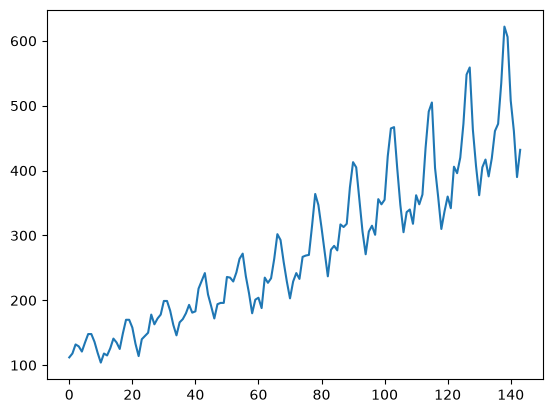

In [144]:
flights['passengers'].plot()

Notice how we just grabbed the columns name, which returns a series.

Pandas takes the data and plots it as a line graph. 

The x axis maps the index and the y axis maps the value of `passengers`.

We can also tell Pandas explicitly to assign `passengers` to the y axis.

<Axes: >

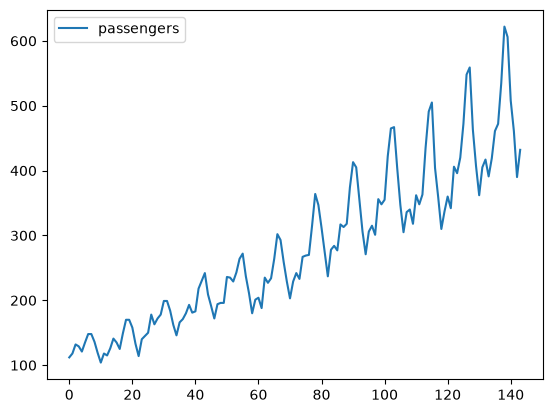

In [56]:
flights.plot(y='passengers')

Now, if we wanted to replace the y axis values with `year` and `month`, you might think we can pass the two columns to the `x` argument, but this won't work.

In [145]:
flights.plot(x=group_cols, y='passengers')

ValueError: x must be a label or position

Python throws a `ValueError` because the `x` argument expects a single value, not a list.

To get around this issue, we could create a new column that combines `year` and `month` into a single string and plot that.

<Axes: xlabel='year_month'>

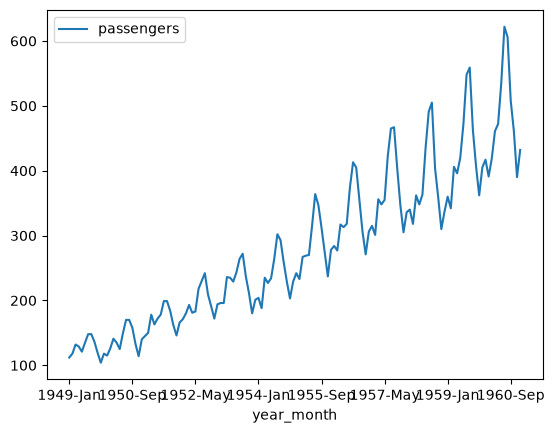

In [146]:
flights['year_month'] = flights['year'].astype('string') + "-" + flights['month'].astype('string')
flights.plot(x='year_month', y='passengers')

This works, but it's cumbersome. 

A better idea is to assign our grouping columns to the index.

Pandas will use the index for the `x` axis if no `x` value is specified.

In [149]:
flights1 = flights.set_index(group_cols)
flights1

passengers year_month
year month                       
1949 Jan           112   1949-Jan
     Feb           118   1949-Feb
     Mar           132   1949-Mar
     Apr           129   1949-Apr
     May           121   1949-May
...                ...        ...
1960 Aug           606   1960-Aug
     Sep           508   1960-Sep
     Oct           461   1960-Oct
     Nov           390   1960-Nov
     Dec           432   1960-Dec

[144 rows x 2 columns]

<Axes: xlabel='year,month'>

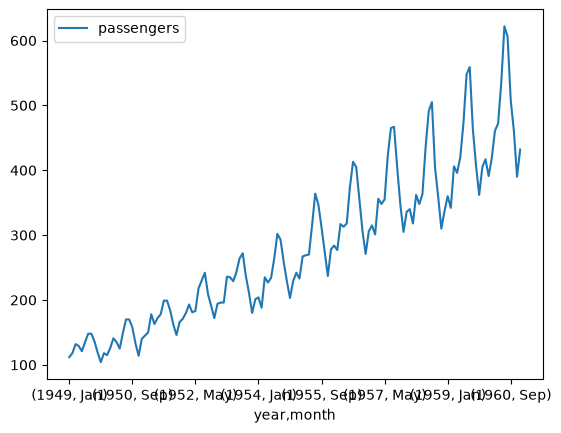

In [150]:
flights1.plot()

We can see that our axis labels look crowded, so let's widen the figure by using the `figsize` argument.

<Axes: xlabel='year,month'>

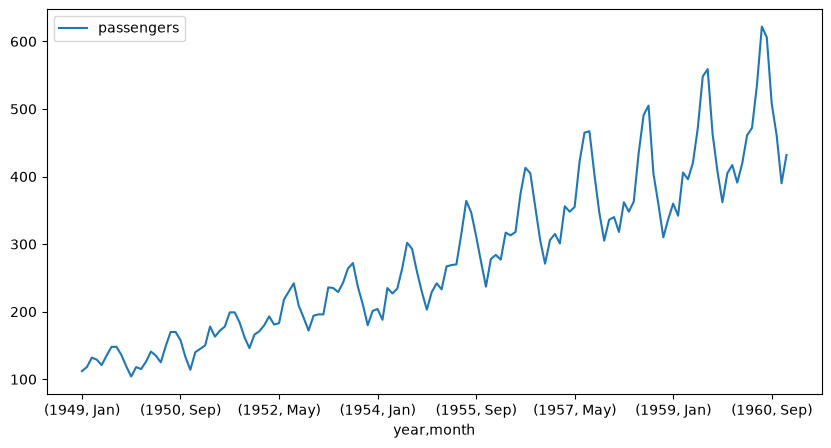

In [151]:
flights1.plot(figsize=(10,5))

> [!note] The units passed to `figsize` are inches. The actual size of your final image in pixels depends the DPI (Dots Per Inch) of your display or save settings.

Notice also that every time we use `.plot()`, Pandas returns a string above the rendered plot:

```
<Axes: xlabel='year,month'>
```

This the name of the object that is being returns. We can hide this from showing by following the plot statement with the expression `plt.show()`. You can of this statement as a directive to PyPlot, which is managing the process of displaying the plot, to show the plot. We'll learn about what `Axes` and PyPlot mean later.

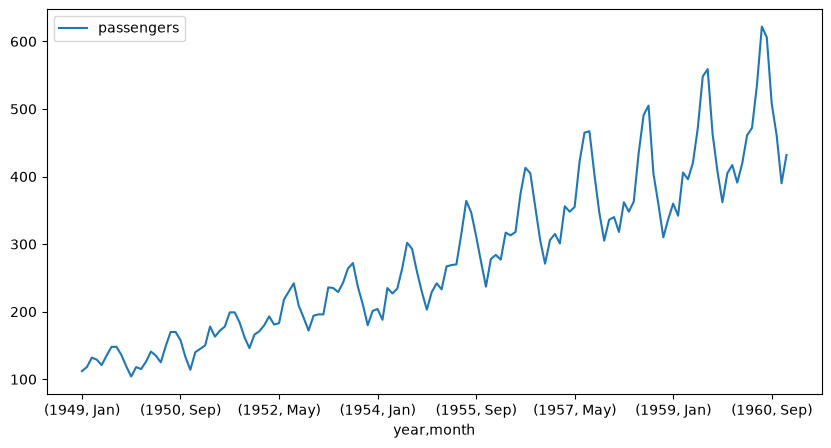

In [153]:
flights1.plot(figsize=(10,5))
plt.show()

The line plot we have create shows that the number of flights has increased over time. We also see that it fluctuates on a yearly basis. The behavior is called **seasonality**.

One way to capture the seasonal structure of the data is to convert the table from tidy to wide form.

As we saw in a previous notebook, we can unstack a table with at least two index columns and a measurement column.

In [154]:
flights2 = flights1['passengers'].unstack()
flights2

month,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
year,,,,,,,,,,,,
1949,112,118,132,129,121,135,148,148,136,119,104,118
1950,115,126,141,135,125,149,170,170,158,133,114,140
1951,145,150,178,163,172,178,199,199,184,162,146,166
1952,171,180,193,181,183,218,230,242,209,191,172,194
1953,196,196,236,235,229,243,264,272,237,211,180,201
1954,204,188,235,227,234,264,302,293,259,229,203,229
1955,242,233,267,269,270,315,364,347,312,274,237,278
1956,284,277,317,313,318,374,413,405,355,306,271,306
1957,315,301,356,348,355,422,465,467,404,347,305,336


Now when we call `.plot()`, each feature, which is unique value of the `month` domain, will be plotted as a separate line.

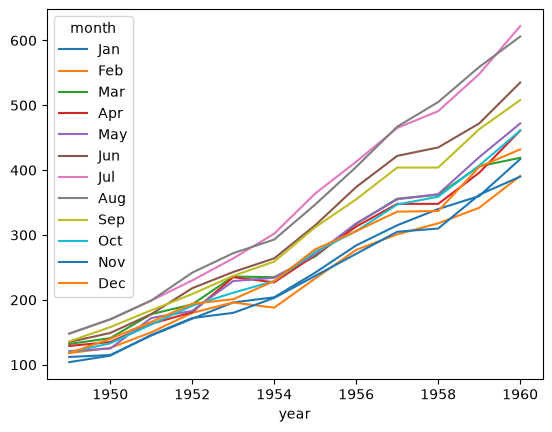

In [155]:
flights2.plot()
plt.show()

A more effective way to represent these data is by transposing the table and then plotting it.

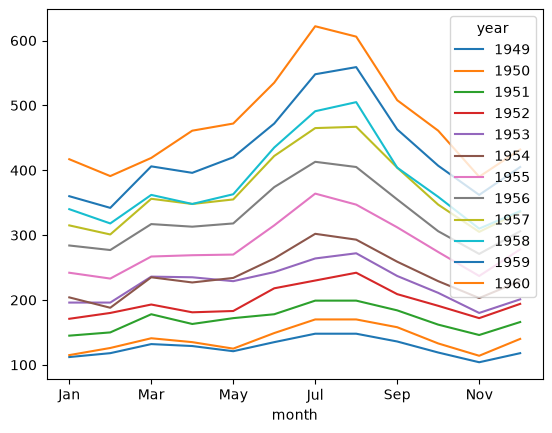

In [157]:
flights2.T.plot()
plt.show()

> [!important] The rule that Pandas is following here is to assign an individual line plot to each column in the dataframe. 

Here we can see clearly both the seasonality of the data and the yearly increase in the number of passengers.

Now, the above plot looks a bit crowded. To remedy this, we can use the `subplots` argument to create separate figures for each plot.

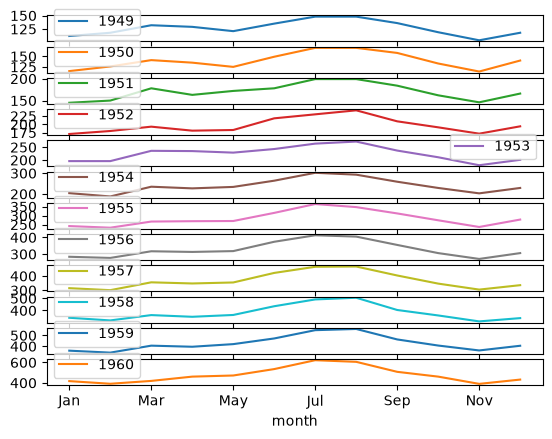

In [116]:
flights2.T.plot(subplots=True)
plt.show()

Again, we can adjust the size of the figure to give us some room.

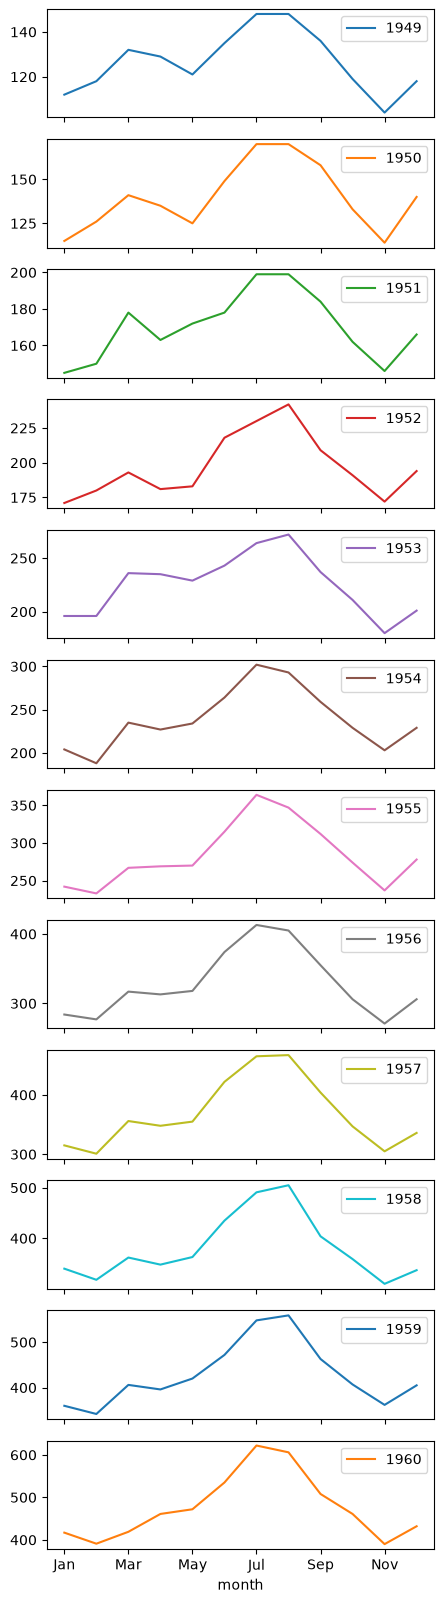

In [166]:
flights2.T.plot(subplots=True, figsize=(5,20))
plt.show()

Note that the y axis on each of the subplots is different.

That's because the plotting engine is clipping it to the range of the data it is plotting.

If we wanted all the subplots to have the same y axis scale, we would set `sharey=True`.

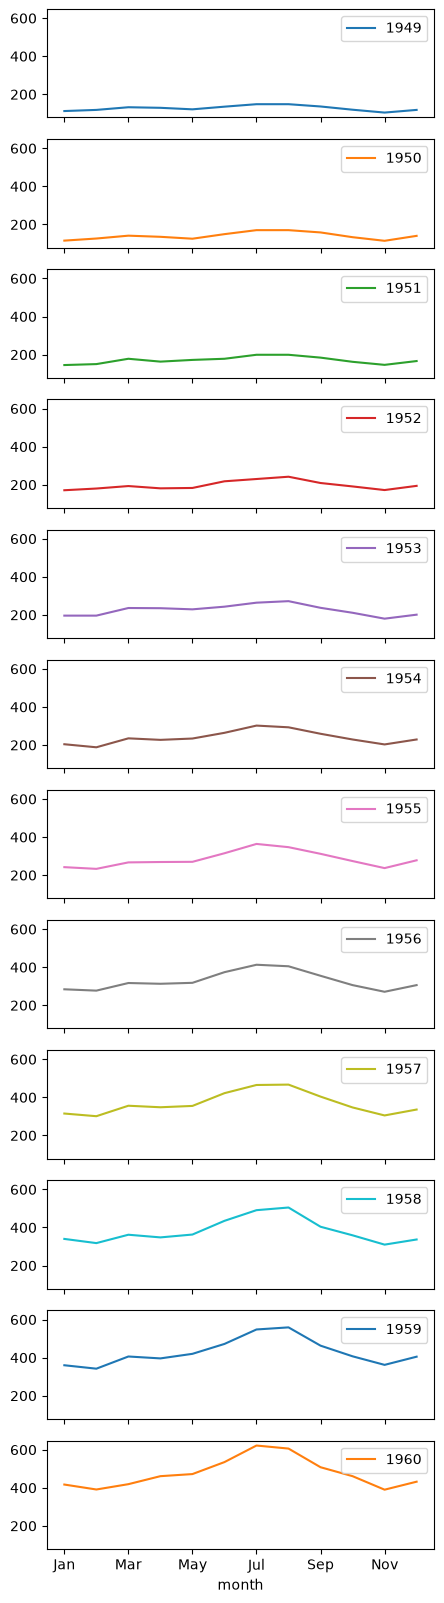

In [164]:
flights2.T.plot(subplots=True, figsize=(5,20), sharey=True)
plt.show()

Now, let's say you want to plot the average number of flights per month in the dataset.

To do that, we can compute the mean of all the columns, which returns a series.

In [168]:
flight_months = flights2.mean()
flight_months

month
Jan    241.750000
Feb    235.000000
Mar    270.166667
Apr    267.083333
May    271.833333
Jun    311.666667
Jul    351.333333
Aug    351.083333
Sep    302.416667
Oct    266.583333
Nov    232.833333
Dec    261.833333
dtype: float64

And then we can plot the series.

While we are at it, let's throw in a title to our plot.

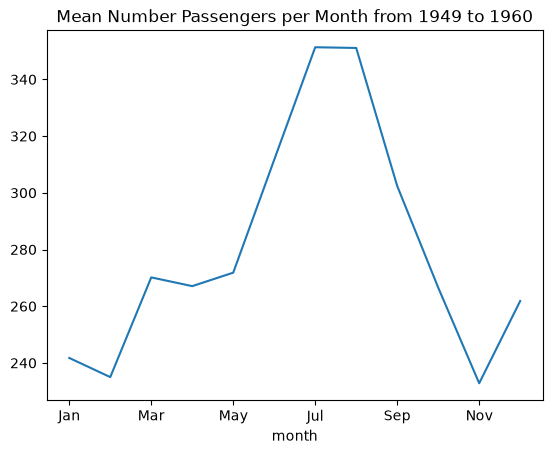

In [175]:
flight_months.plot()
plt.title("Mean Number Passengers per Month from 1949 to 1960")
plt.show()

To emphasize that our data are discrete, we can style the plot using dots and lines by using the `style` argument.

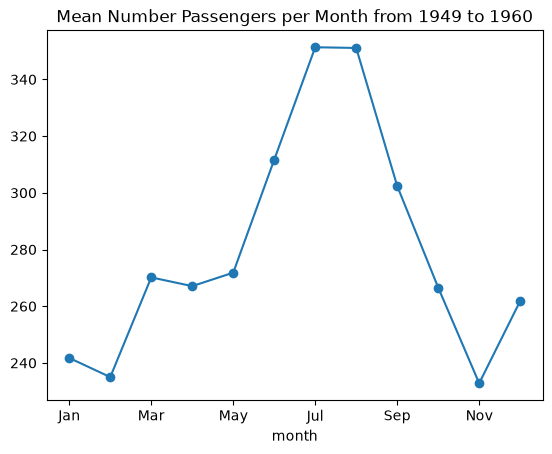

In [177]:
flight_months.plot(style='o-')
plt.title("Mean Number Passengers per Month from 1949 to 1960")
plt.show()

We could also represent this plot as a bar chart by assigning `bar` to the `kind` argument.

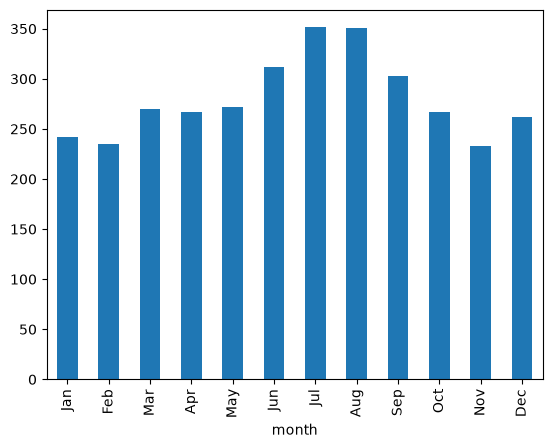

In [178]:
flights2.mean().T.plot(kind='bar')
plt.show()

To make the dates read horizontally, we can set `rot` to $0\degree$.

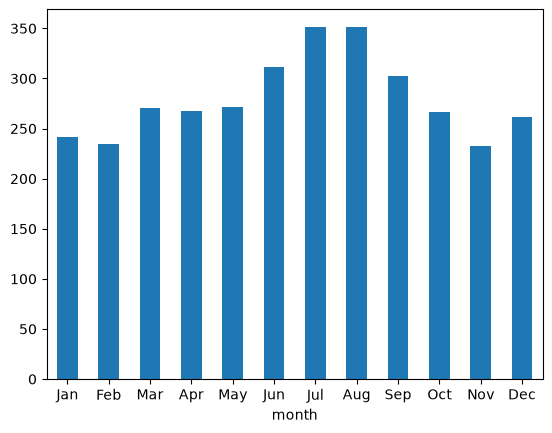

In [109]:
flights2.mean().T.plot(kind='bar', rot=0)
plt.show()

We can also set the `kind` to a boxplot.

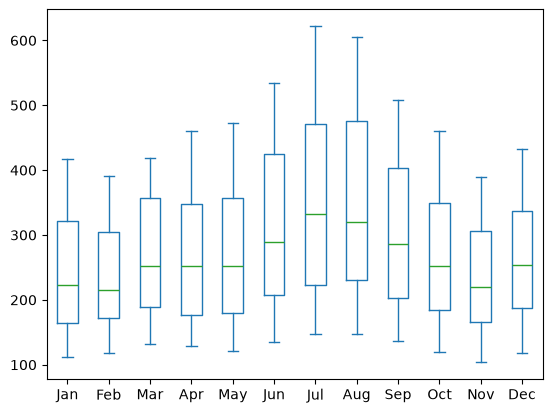

In [180]:
flights2.plot(kind='box')
plt.show()

## Summary

Pandas' `plot` method assumes that the x axis is the index of the dataframe or series, unless specified by the `x` argument.

If specified by `x`, the value can't be a list of columns.

If no value for `y` is given, Pandas assumes that you want to plot all the numeric columns.

Each of the plotted columns will be assigned a line.

The `plot` method has a `kind` argument to specify other kinds of plot, including bar plots, box plot, and other kinds. 

The default plot type is a line graph. 

We will review individually all this plots Pandas can make.

## For more information

Check out Pandas' [tutorial](https://pandas.pydata.org/docs/user_guide/visualization.html) and [documention](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html) on its plotting capabilities.